In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, balanced_accuracy_score

In [4]:
DATASET_PATH = 'data/dataset_split/trainval'
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    shuffle=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)
NUM_CLASSES = len(train_data.class_indices)
CLASS_NAMES = list(train_data.class_indices.keys())
print(f"\nClasses: {NUM_CLASSES}")
print(train_data.class_indices)

Found 83829 images belonging to 36 classes.
Found 20941 images belonging to 36 classes.

Classes: 36
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'a': 10, 'b': 11, 'c': 12, 'd': 13, 'e': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'j': 19, 'k': 20, 'l': 21, 'm': 22, 'n': 23, 'o': 24, 'p': 25, 'q': 26, 'r': 27, 's': 28, 't': 29, 'u': 30, 'v': 31, 'w': 32, 'x': 33, 'y': 34, 'z': 35}


In [5]:
classes = np.unique(train_data.classes)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_data.classes
)
class_weight = dict(zip(classes, weights))
class_weight = {c: float(np.sqrt(w)) for c, w in class_weight.items()}

In [8]:
model = models.Sequential([
    tf.keras.Input(shape=(160, 160, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),#160 --> 80

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    #layers.Conv2D(256, 3, activation='relu', padding='same'),
    #layers.BatchNormalization(),
    #layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),

    # classification
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'model/asl_cnn_3.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,812 (514.89 KB)

 Trainable params: 131,364 (513.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight = class_weight
)

Epoch 1/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.4901 - loss: 1.5723
Epoch 1: val_accuracy improved from None to 0.17239, saving model to model/asl_cnn_3.keras

Epoch 1: finished saving model to model/asl_cnn_3.keras
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 2263s 864ms/step - accuracy: 0.6607 - loss: 1.0667 - val_accuracy: 0.1724 - val_loss: 5.0152 - learning_rate: 0.0010
Epoch 2/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.8413 - loss: 0.5266
Epoch 2: val_accuracy did not improve from 0.17239
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 2099s 801ms/step - accuracy: 0.8520 - loss: 0.4921 - val_accuracy: 0.0356 - val_loss: 34.1412 - learning_rate: 0.0010
Epoch 3/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.8776 - loss: 0.4049
Epoch 3: val_accuracy did not improve from 0.17239
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 2042s 779ms/step - accuracy: 0.8833 - loss: 0.3913 - val_accuracy: 0.0723 - val_loss: 47.7544 - learning_rate: 0.0010
Epoch 4/20
2620/2620 ━━━━━━━━━━━━━

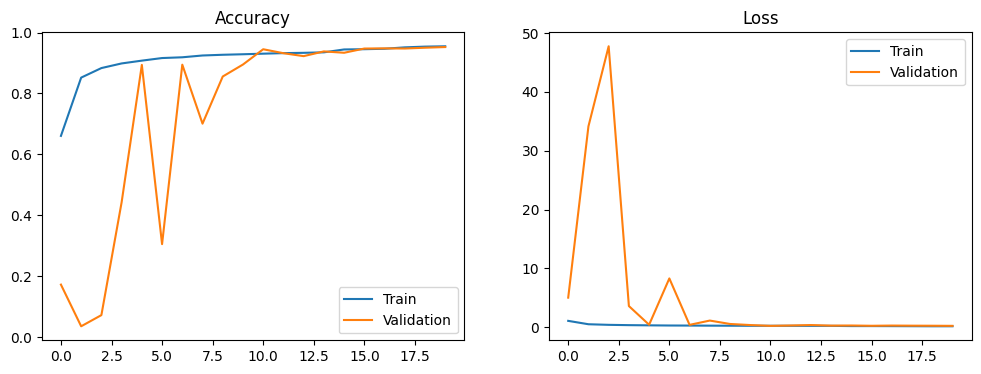

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.savefig('png/training_history_3.png')
plt.show()

0_0

In [13]:
best_model = models.load_model('model/asl_cnn_3.keras')
best_model.evaluate(val_data, verbose=0)

[0.21948322653770447, 0.9523422718048096]

In [14]:
TEST_PATH = 'data/dataset_split/test'
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255)

test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

Found 650 images belonging to 36 classes.


In [15]:
test_loss, test_acc = best_model.evaluate(test_data, verbose=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.9554 - loss: 0.2035


In [16]:
test_data.reset()
proba = best_model.predict(test_data, verbose=0)
y_pred = np.argmax(proba, axis=1)
y_true = test_data.classes

macro_f1 = f1_score(y_true, y_pred, average="macro")
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"TEST macro F1: {macro_f1:.4f}")
print(f"TEST balanced accuracy: {bal_acc:.4f}")

TEST macro F1: 0.9555
TEST balanced accuracy: 0.9548


In [17]:
idx_to_class = {v: k for k, v in test_data.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        14
           4       1.00      0.86      0.92        14
           5       0.88      1.00      0.93        14
           6       1.00      1.00      1.00        11
           7       0.93      1.00      0.97        14
           8       1.00      0.92      0.96        12
           9       1.00      1.00      1.00        14
           a       0.83      1.00      0.91        20
           b       0.95      1.00      0.98        20
           c       0.94      0.85      0.89        20
           d       0.86      0.95      0.90        20
           e       0.83      1.00      0.91        20
           f       1.00      0.95      0.97        20
           g       0.90      0.95      0.93        20
           h       1.00    

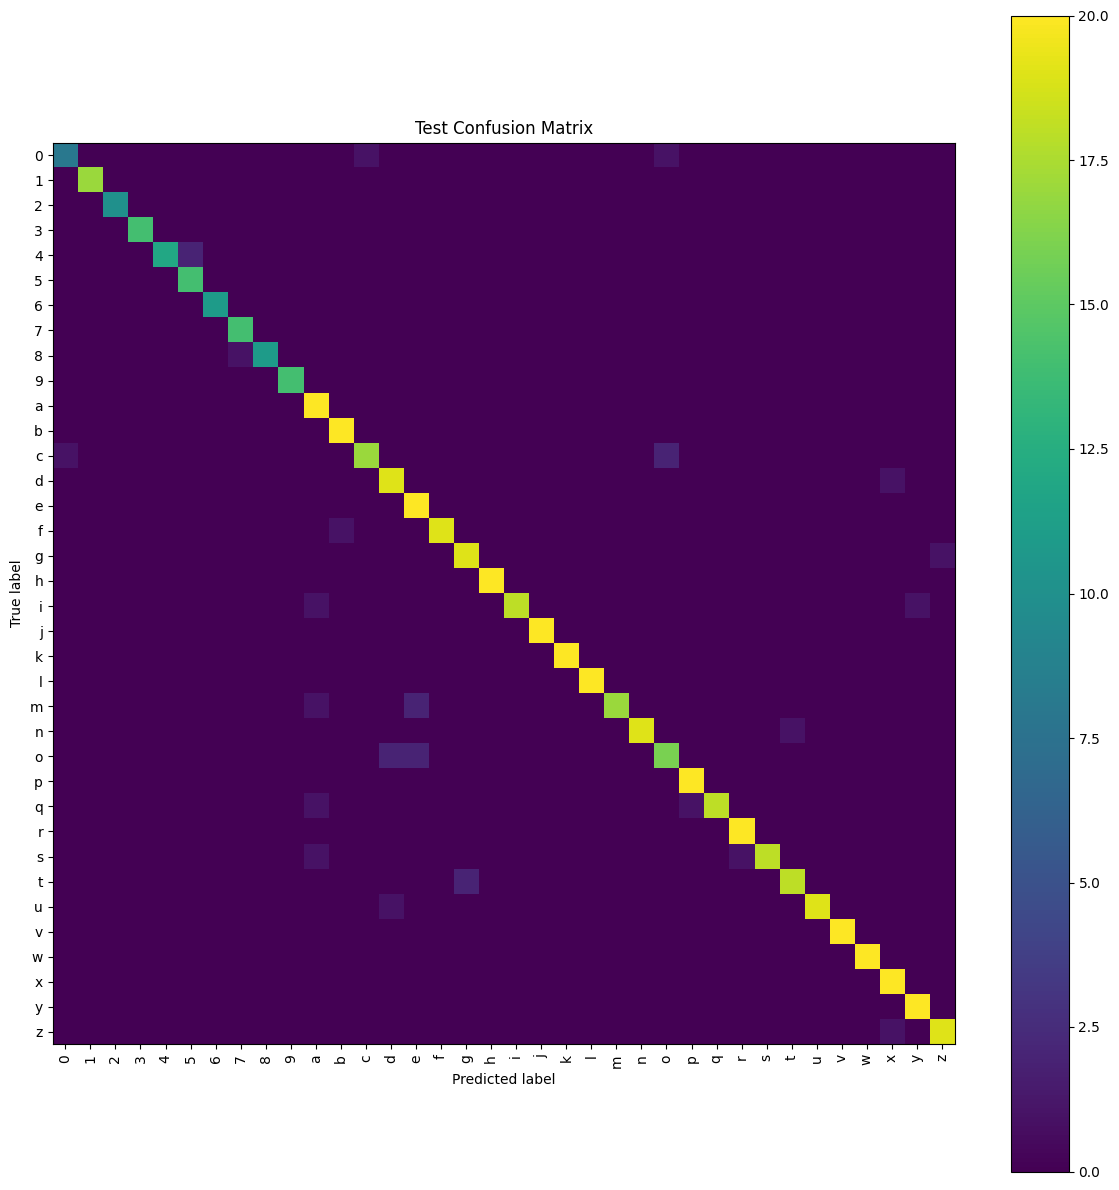

In [18]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

plt.figure(figsize=(12, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Test Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("png/test_confusion_matrix_3.png", dpi=200)
plt.show()

In [19]:
digit_ids = [test_data.class_indices[str(d)] for d in range(10)]
mask = np.isin(y_true, digit_ids)

digits_macro_f1 = f1_score(np.array(y_true)[mask], np.array(y_pred)[mask], average="macro")
digits_bal_acc  = balanced_accuracy_score(np.array(y_true)[mask], np.array(y_pred)[mask])

print(f"Numbers macro F1: {digits_macro_f1:.4f}")
print(f"Numbers balanced accuracy: {digits_bal_acc:.4f}")

Numbers macro F1: 0.8056
Numbers balanced accuracy: 0.9574


C:\Users\Admin\PycharmProjects\ASL-recognition\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
